# Treinamento da MarkerNet — MoNuSeg (treino oficial + validação no teste oficial)

Este notebook treina a **MarkerNet** usando a rede final congelada (ScribblePrompt) como camada de loss,
incorporando as correções da investigação (`docs/investigacao_experimento_1.md`):

1. **Split sem vazamento de teste (C6):** treino nas **30 imagens oficiais de treino** do MoNuSeg e
   validação nas **14 oficiais de teste** — nada de misturar o conjunto de teste no treino;
2. **Dados pré-processados carregados do disco** — Cellpose + RGBA + mapa de distância persistidos em
   **1000×1000** (P7) em `data_source/MoNuSegPreprocessed/` pelo notebook
   `notebooks/preprocessing/preprocessamento_monuseg_persistido.ipynb` (sem reprocessamento a cada experimento);
3. **Batches com mais de 1 imagem** (batch size 4) para estabilizar BatchNorm e reduzir ruído do gradiente (P4);
4. **Treinamento** da MarkerNet através da rede final congelada (ScribblePrompt), com:
   - MarkerNet em modo `train()` (P3);
   - scribbles *sharpened* (quase binários) — mais próximos da distribuição de treino do ScribblePrompt (C2);
   - loss `Dice + RMSE + Size + DMap` — o mapa de distância agora supervisiona os **marcadores** diretamente (P11/C3/C4);
   - `SizeTerm` simétrico em torno de 1.0 (P10);
   - grad clipping + scheduler CosineAnnealing (P5);
   - callback de **grad-norm** para diagnóstico de gradiente morto (P1/E1);
5. **Avaliação** (curvas de loss, grad-norm, visualização) e **checkpoint** persistido (P12/E8).

Fluxo do pipeline de treinamento:

```
rgba → MarkerStep (MarkerNet diferenciável, train()) → markers
→ FrozenSegmentationStep (ScribblePrompt congelado) → segmentation
→ LossComposer (dice + rmse + size + dmap) → backward até a MarkerNet
```

> **Configurações:** 50 épocas, batch de 4 imagens, resolução de trabalho 1000×1000, lr 1e-4 com
> CosineAnnealing, grad clip 1.0 e checkpoint salvo ao final.

## 0. Setup

**Colab:** instale as dependências na célula abaixo (`requirements.txt` fixa todas as versões; torch/torchvision preservam a build GPU do Colab).

**Local:** garanta que o `.venv` esteja ativo com as dependências instaladas.


In [9]:
# Robust setup: local or Colab — encontra a raiz do repositório e insere no sys.path
import sys
import os
repo_dir_name = 'cell-fuzzy-seg'

def find_repo_root(start='.'):
    p = os.path.abspath(start)
    prev = None
    while p != prev:
        if os.path.isdir(os.path.join(p, 'src')) or os.path.exists(os.path.join(p, 'pyproject.toml')) or os.path.isdir(os.path.join(p, '.git')):
            return p
        prev = p
        p = os.path.dirname(p)
    return None

if 'google.colab' in sys.modules:
    # tenta encontrar em /content, senão clona
    base = '/content'
    repo_root = find_repo_root(base) or os.path.join(base, repo_dir_name)
    if not os.path.exists(repo_root):
        get_ipython().system(f"git clone --branch feat/experiment_1 https://github.com/Pedro-io/cell-fuzzy-seg.git {repo_root}")
else:
    repo_root = find_repo_root(os.getcwd())

# fallback: usa cwd
if repo_root is None:
    repo_root = os.getcwd()

# muda para a raiz do repositório e garante que ela esteja no sys.path
try:
    os.chdir(repo_root)
except Exception:
    pass
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

print('Notebook CWD:', os.getcwd())
print('sys.path[0]:', sys.path[0])


Notebook CWD: /content/cell-fuzzy-seg
sys.path[0]: /content/cell-fuzzy-seg


In [10]:
# Instala as dependências (apenas no Colab / primeira execução)
import sys

if "google.colab" in sys.modules:
    get_ipython().system("python -m pip install -r requirements.txt -q")
else:
    print("Ambiente local: verifique se as dependências estão instaladas no .venv.")


In [11]:
%ls

CITATION.cff  docs/      notebooks/        README.md         tests/
configs/      jornal.md  pipeline_test.py  requirements.txt
data_source/  LICENSE    pyproject.toml    src/


## 1. Imports e dispositivo

In [12]:
import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


from src.pipeline.training_pipeline import TrainingPipeline
from src.pipeline.steps.inference.marker_step import MarkerStep
from src.pipeline.steps.inference.frozen_segmentation_step import FrozenSegmentationStep
from src.models.networks.marker_unet import MarkerUNet
from src.models.configs.marker_unet_config import UNET_CONFIG
from src.models.networks.final_segmentation.base_final_segmentation import BaseFinalSegmentation
from src.losses.terms import DiceTerm, RMSETerm, SizeTerm, DMapTerm, TVTerm, BorderTerm
from src.losses.loss_composer import LossComposer
from src.training.trainer import Trainer
from src.training.training_loop import TrainingLoop
from src.training.callbacks import GradNormCallback

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
print(f"Device: {DEVICE}")

Device: cuda


## 2. Carregar dados pré-processados (treino oficial e teste oficial separados)

Carregamos do disco os dados **já pré-processados** em `data_source/MoNuSegPreprocessed/` (gerados
pelo notebook `notebooks/preprocessing/preprocessamento_monuseg_persistido.ipynb`): Cellpose + RGBA + mapa de distância
persistidos em **1000×1000** (P7) — nada de reprocessar a cada experimento.

O split é **sem vazamento (C6)**: treino = 30 imagens oficiais, validação = 14 oficiais de teste.
O conjunto de teste é usado apenas para validação — qualquer métrica reportada aqui é comparável com
a literatura do MoNuSeg. A resolução de trabalho (`WORK_SIZE`) é lida do `meta.json` gravado junto
com os dados.

In [13]:
PREPROCESSED_DIR = os.path.join("data_source", "MoNuSegPreprocessed")

# meta.json foi gravado pelo notebook de pré-processamento persistido.
with open(os.path.join(PREPROCESSED_DIR, "meta.json"), encoding="utf-8") as f:
    meta = json.load(f)
WORK_SIZE = meta["work_size"]

print("meta:", {k: v for k, v in meta.items() if k != "keys"})
print("keys persistidas:", meta["keys"])


def load_preprocessed(split):
    """Reconstrói as amostras pré-processadas de um split a partir do disco."""
    base = os.path.join(PREPROCESSED_DIR, split)
    ids = sorted(
        f[:-4] for f in os.listdir(os.path.join(base, "image")) if f.endswith(".npy")
    )
    samples = []
    for image_id in ids:
        samples.append(
            {
                "id": image_id,
                "image": np.load(os.path.join(base, "image", f"{image_id}.npy")),
                "rgba": np.load(os.path.join(base, "rgba", f"{image_id}.npy")),
                "ground_truth": np.load(os.path.join(base, "ground_truth", f"{image_id}.npy")),
                "distance_map": np.load(os.path.join(base, "distance_map", f"{image_id}.npy")),
            }
        )
    return samples


train_preprocessed = load_preprocessed("train")
test_preprocessed = load_preprocessed("test")
print(f"Treino (oficial): {len(train_preprocessed)} | Teste (oficial): {len(test_preprocessed)}")
print("ids de treino:", [s["id"] for s in train_preprocessed])
print("ids de teste:", [s["id"] for s in test_preprocessed])

meta: {'work_size': 1000, 'segmentation_source': 'cellpose', 'splits': {'train': 30, 'test': 14}, 'created_at': '2026-08-16 19:28:31'}
keys persistidas: ['image', 'segmentation', 'rgba', 'ground_truth', 'distance_map']
Treino (oficial): 30 | Teste (oficial): 14
ids de treino: ['TCGA-18-5592-01Z-00-DX1', 'TCGA-21-5784-01Z-00-DX1', 'TCGA-21-5786-01Z-00-DX1', 'TCGA-38-6178-01Z-00-DX1', 'TCGA-49-4488-01Z-00-DX1', 'TCGA-50-5931-01Z-00-DX1', 'TCGA-A7-A13E-01Z-00-DX1', 'TCGA-A7-A13F-01Z-00-DX1', 'TCGA-AR-A1AK-01Z-00-DX1', 'TCGA-AR-A1AS-01Z-00-DX1', 'TCGA-AY-A8YK-01A-01-TS1', 'TCGA-B0-5698-01Z-00-DX1', 'TCGA-B0-5710-01Z-00-DX1', 'TCGA-B0-5711-01Z-00-DX1', 'TCGA-CH-5767-01Z-00-DX1', 'TCGA-DK-A2I6-01A-01-TS1', 'TCGA-E2-A14V-01Z-00-DX1', 'TCGA-E2-A1B5-01Z-00-DX1', 'TCGA-G2-A2EK-01A-02-TSB', 'TCGA-G9-6336-01Z-00-DX1', 'TCGA-G9-6348-01Z-00-DX1', 'TCGA-G9-6356-01Z-00-DX1', 'TCGA-G9-6362-01Z-00-DX1', 'TCGA-G9-6363-01Z-00-DX1', 'TCGA-HE-7128-01Z-00-DX1', 'TCGA-HE-7129-01Z-00-DX1', 'TCGA-HE-7130-01Z-00

## 3. Dados pré-processados — verificação

O pré-processamento (Cellpose + RGBA + mapa de distância) **não é refeito aqui**: ele foi executado
**uma única vez** pelo notebook `notebooks/preprocessing/preprocessamento_monuseg_persistido.ipynb` e persistido em
`data_source/MoNuSegPreprocessed/` (o `SaveResultsStep` delega a gravação ao `src/io/output_writer.py`).
Esta seção apenas verifica que os dados carregados estão na resolução de trabalho (P7) e com valores
dentro das faixas esperadas.

> Se você ainda não rodou o notebook de pré-processamento persistido, rode-o antes deste.

In [14]:
# Verificação: shapes na resolução de trabalho e faixas de valores esperadas.
assert all(s["image"].shape[:2] == (WORK_SIZE, WORK_SIZE) for s in train_preprocessed + test_preprocessed)
print(f"OK: todas as imagens em {WORK_SIZE}x{WORK_SIZE}")

for split_name, samples in [("treino", train_preprocessed), ("teste", test_preprocessed)]:
    s = samples[0]
    print(f"\n{split_name}: {s['id']}")
    for k in ["image", "rgba", "ground_truth", "distance_map"]:
        v = s[k]
        print(f"  {k:15s} | shape={str(v.shape):20s} | dtype={v.dtype} | min={v.min():.3f} | max={v.max():.3f}")
    assert s["rgba"].shape[-1] == 4
    assert 0.0 <= s["rgba"].min() and s["rgba"].max() <= 1.0
    assert 0.0 <= s["distance_map"].min() and s["distance_map"].max() <= 1.0
print("\nOK: dados pré-processados consistentes.")

OK: todas as imagens em 1000x1000

treino: TCGA-18-5592-01Z-00-DX1
  image           | shape=(1000, 1000, 3)      | dtype=uint8 | min=8.000 | max=255.000
  rgba            | shape=(1000, 1000, 4)      | dtype=float32 | min=0.000 | max=1.000
  ground_truth    | shape=(1000, 1000)         | dtype=uint8 | min=0.000 | max=1.000
  distance_map    | shape=(1000, 1000)         | dtype=float32 | min=0.000 | max=1.000

teste: TCGA-2Z-A9J9-01A-01-TS1
  image           | shape=(1000, 1000, 3)      | dtype=uint8 | min=0.000 | max=255.000
  rgba            | shape=(1000, 1000, 4)      | dtype=float32 | min=0.000 | max=1.000
  ground_truth    | shape=(1000, 1000)         | dtype=uint8 | min=0.000 | max=1.000
  distance_map    | shape=(1000, 1000)         | dtype=float32 | min=0.000 | max=1.000

OK: dados pré-processados consistentes.


## 4. Batches de treino e validação (batch size > 1)

Montamos os batches a partir das amostras **pré-processadas carregadas do disco** (1000²).
**Diferente do experimento anterior (1 imagem por batch), empilhamos 4 imagens por batch (P4)**:
gradientes por amostra são menos ruidosos e as BatchNorms da MarkerNet (agora em `train()` — P3)
recebem estatísticas de lote estáveis.

O split é **sem vazamento (C6)**: treino = 30 imagens oficiais, validação = 14 oficiais de teste.
O `distance_map` foi calculado sobre o GT **na resolução de trabalho** durante o pré-processamento
persistido (o mapa deve ser calculado sobre a máscara já redimensionada).

In [15]:
BATCH_SIZE = 4  # >1 imagem por batch (P4): estabiliza BatchNorm e reduz ruído do gradiente


def build_batch(samples, augment=False):
    """Constrói um batch empilhando as amostras pré-processadas (todas em WORK_SIZE)."""
    images, rgbs, gts, dmaps = [], [], [], []
    for s in samples:
        img = s["image"]
        rgba = s["rgba"]
        gt = s["ground_truth"]
        dmap = s["distance_map"]

        if augment:
            # Augmentação simples (P6): rotação 90° e flips aplicados de forma
            # conjunta a imagem, rgba, gt e dmap.
            k = np.random.randint(0, 4)
            if k:
                img = np.rot90(img, k).copy()
                rgba = np.rot90(rgba, k).copy()
                gt = np.rot90(gt, k).copy()
                dmap = np.rot90(dmap, k).copy()
            if np.random.rand() < 0.5:
                img = np.fliplr(img).copy()
                rgba = np.fliplr(rgba).copy()
                gt = np.fliplr(gt).copy()
                dmap = np.fliplr(dmap).copy()
            if np.random.rand() < 0.5:
                img = np.flipud(img).copy()
                rgba = np.flipud(rgba).copy()
                gt = np.flipud(gt).copy()
                dmap = np.flipud(dmap).copy()

        images.append(torch.from_numpy(img.transpose(2, 0, 1)).float())          # (3,H,W)
        rgbs.append(torch.from_numpy(rgba.transpose(2, 0, 1)).float())           # (4,H,W)
        gts.append(torch.from_numpy(gt.astype(np.float32))[None])                # (1,H,W)
        dmaps.append(torch.from_numpy(dmap.astype(np.float32))[None])            # (1,H,W)

    return {
        "id": [s["id"] for s in samples],
        "image": torch.stack(images),        # (B,3,H,W)
        "rgba": torch.stack(rgbs),           # (B,4,H,W)
        "ground_truth": torch.stack(gts),    # (B,1,H,W)
        "distance_map": torch.stack(dmaps),  # (B,1,H,W)
    }


def make_batches(samples, batch_size, augment):
    return [
        build_batch(samples[i:i + batch_size], augment=augment)
        for i in range(0, len(samples), batch_size)
    ]


# Split sem vazamento (C6): treino = 30 oficiais, validação = 14 oficiais de teste.
train_batches = make_batches(train_preprocessed, BATCH_SIZE, augment=True)
val_batches = make_batches(test_preprocessed, BATCH_SIZE, augment=False)

print(
    f"treino: {len(train_preprocessed)} imagens em {len(train_batches)} batches "
    f"({BATCH_SIZE} por batch) | validação: {len(test_preprocessed)} imagens em {len(val_batches)} batches"
)
b = train_batches[0]
for k, v in b.items():
    print(k, tuple(v.shape) if hasattr(v, "shape") else v)


treino: 30 imagens em 8 batches (4 por batch) | validação: 14 imagens em 4 batches
id ['TCGA-18-5592-01Z-00-DX1', 'TCGA-21-5784-01Z-00-DX1', 'TCGA-21-5786-01Z-00-DX1', 'TCGA-38-6178-01Z-00-DX1']
image (4, 3, 1000, 1000)
rgba (4, 4, 1000, 1000)
ground_truth (4, 1, 1000, 1000)
distance_map (4, 1, 1000, 1000)


## 5. Redes

- **MarkerNet** (treinável) — `smp.Unet` com encoder ResNet34 e 4 canais de entrada (RGBA);
- **Rede final congelada** — `ScribblePromptingNetwork` (ScribblePrompt-UNet v1). Se o pacote ou o
  checkpoint não estiverem disponíveis, usamos uma **rede final dummy congelada** apenas para validar
  o fluxo de gradiente.

In [16]:
# --- MarkerNet (treinável) ---
marker_net = MarkerUNet(config=UNET_CONFIG).to(DEVICE)
print("MarkerNet params:", sum(p.numel() for p in marker_net.parameters()))

# --- Rede final congelada (ScribblePrompt) ---
FINAL_NET = None
try:
    from src.models.networks.final_segmentation.scribble_prompting_network import ScribblePromptingNetwork
    os.makedirs("checkpoints", exist_ok=True)
    ckpt = ScribblePromptingNetwork.download_checkpoint("checkpoints")
    # scribble_mode="sharpened" (C2): converte os marcadores em canais quase binários
    # (pos/neg complementares), mais próximos da distribuição de treino do ScribblePrompt.
    FINAL_NET = ScribblePromptingNetwork(
        checkpoint=ckpt,
        device=DEVICE,
        resize_output=True,
        scribble_mode="sharpened",
        scribble_temperature=10.0,
    )
    print("Rede final: ScribblePrompt (congelada) — scribbles sharpened (C2)")
except Exception as e:
    print(f"[fallback] ScribblePrompt indisponível: {type(e).__name__}: {e}")

if FINAL_NET is None:
    class DummyFinalNetwork(BaseFinalSegmentation):
        # Rede final congelada mínima (apenas para validar o fluxo de gradiente).
        def __init__(self):
            super().__init__(config={})
            self.conv = nn.Sequential(
                nn.Conv2d(4, 16, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(16, 1, 3, padding=1),
            )
            self.conv.requires_grad_(False)  # congelada: o gradiente flui ATRAVÉS dela

        def forward(self, data):
            img = data["image"]
            scribbles = data["scribbles"]
            if isinstance(img, np.ndarray):
                if img.ndim == 2:
                    img = np.stack([img] * 3, axis=-1)
                img = torch.from_numpy(img.transpose(2, 0, 1)).float().unsqueeze(0)
            img = img.to(DEVICE)
            if img.max() > 1.0:
                img = img / 255.0
            s = scribbles.float().to(DEVICE)
            if s.ndim == 3:
                s = s.unsqueeze(0)
            x = torch.cat([img, s], dim=1)
            return torch.sigmoid(self.conv(x))

        def predict(self, data):
            # BaseNetwork exige predict() (abstractmethod).
            with torch.no_grad():
                return self.forward(data)

    FINAL_NET = DummyFinalNetwork().to(DEVICE)
    print("Rede final: DummyFrozen (fallback)")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

2026-08-16 19:30:14.468 | INFO     | src.models.networks.final_segmentation.scribble_prompting_network:download_checkpoint:383 - [ScribblePromptingNetwork] Baixando checkpoint de https://www.dropbox.com/scl/fi/pnw88n05irnv5z1snlklr/ScribblePrompt_unet_v1_nf192_res128.pt?rlkey=dr8xvkf0wj2r082h1zzpcmz5o&dl=1


MarkerNet params: 24439505


2026-08-16 19:30:16.898 | INFO     | src.models.networks.final_segmentation.scribble_prompting_network:download_checkpoint:385 - [ScribblePromptingNetwork] Checkpoint salvo em checkpoints/ScribblePrompt_unet_v1_nf192_res128.pt
2026-08-16 19:30:16.963 | INFO     | src.models.networks.final_segmentation.scribble_prompting_network:__init__:158 - [ScribblePromptingNetwork] Inicializada (version=v1, device=cuda, input_size=(128, 128))


Rede final: ScribblePrompt (congelada) — scribbles sharpened (C2)


## 6. TrainingPipeline — forward diferenciável

`MarkerStep(differentiable=True)` preserva o grafo (sem `no_grad`, sem binarização) e coloca a
MarkerNet em `train()` (P3). `FrozenSegmentationStep` repassa `{image, scribbles}` à rede final.
O resultado `segmentation` alimenta a loss.

In [17]:
marker_step = MarkerStep(model=marker_net, differentiable=True, device=DEVICE)
final_step = FrozenSegmentationStep(final_network=FINAL_NET, device=DEVICE)
training_pipeline = TrainingPipeline([marker_step, final_step])

out = training_pipeline.run(train_batches[0], verbose=False)
print("markers:", tuple(out["markers"].shape), out["markers"].dtype)
print("segmentation:", tuple(out["segmentation"].shape), out["segmentation"].dtype)
print("markers range:", float(out["markers"].min()), float(out["markers"].max()))
print("seg range:", float(out["segmentation"].min()), float(out["segmentation"].max()))
print("MarkerNet em train():", marker_net.model.training)  # deve ser True (P3)


2026-08-16 19:30:17.393 | INFO     | src.pipeline.steps.inference.marker_step:__init__:86 - [MarkerStep] Initialized on cuda (differentiable=True)
2026-08-16 19:30:17.395 | INFO     | src.pipeline.steps.inference.frozen_segmentation_step:__init__:67 - [FrozenSegmentationStep] Initialized on cuda
2026-08-16 19:30:18.059 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:130 - [MarkerStep] Generated markers with shape (4, 1, 1000, 1000)
2026-08-16 19:30:18.180 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (4, 1, 1000, 1000)


markers: (4, 1, 1000, 1000) torch.float32
segmentation: (4, 1, 1000, 1000) torch.float32
markers range: 0.05861353874206543 0.9999768733978271
seg range: 1.7011132086297565e-14 0.9931901097297668
MarkerNet em train(): True


/tmp/ipykernel_10494/4061798686.py:8: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("markers range:", float(out["markers"].min()), float(out["markers"].max()))


## 7. Validação de gradiente e congelamento

A loss (sobre `segmentation`) deve alcançar os pesos da **MarkerNet** e **não** deve gerar gradiente
na rede final (congelada). Além da existência do gradiente, medimos agora a **magnitude** (grad-norm
L2) — o experimento anterior só verificava não-`None`, o que não detectava gradiente morto (P1).

In [18]:
marker_net.zero_grad()
loss_check = out["segmentation"].mean()
loss_check.backward()

marker_grads = [p for p in marker_net.parameters() if p.grad is not None]
final_grads = [p for p in FINAL_NET.parameters() if p.grad is not None]
grad_norm = torch.sqrt(sum((p.grad.detach() ** 2).sum() for p in marker_grads)) if marker_grads else torch.tensor(0.0)

print(f"MarkerNet com gradiente: {len(marker_grads)} tensores | grad-norm L2: {grad_norm.item():.3e}")
print(f"Rede final com gradiente (deve ser 0): {len(final_grads)}")

assert len(marker_grads) > 0, "Nenhum gradiente chegou à MarkerNet!"
assert len(final_grads) == 0, "A rede final não deve acumular gradiente (congelada)!"
if grad_norm.item() < 1e-6:
    print("[aviso] grad-norm muito baixo — gradiente possivelmente morto (P1); acompanhe o GradNormCallback no treino.")
else:
    print("OK: gradiente flui até a MarkerNet; rede final congelada.")


MarkerNet com gradiente: 140 tensores | grad-norm L2: 3.810e+01
Rede final com gradiente (deve ser 0): 0
OK: gradiente flui até a MarkerNet; rede final congelada.


2026-08-16 19:30:19.798 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:130 - [MarkerStep] Generated markers with shape (4, 1, 1000, 1000)
2026-08-16 19:30:19.854 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (4, 1, 1000, 1000)
2026-08-16 19:30:19.942 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:130 - [MarkerStep] Generated markers with shape (4, 1, 1000, 1000)
2026-08-16 19:30:19.997 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (4, 1, 1000, 1000)


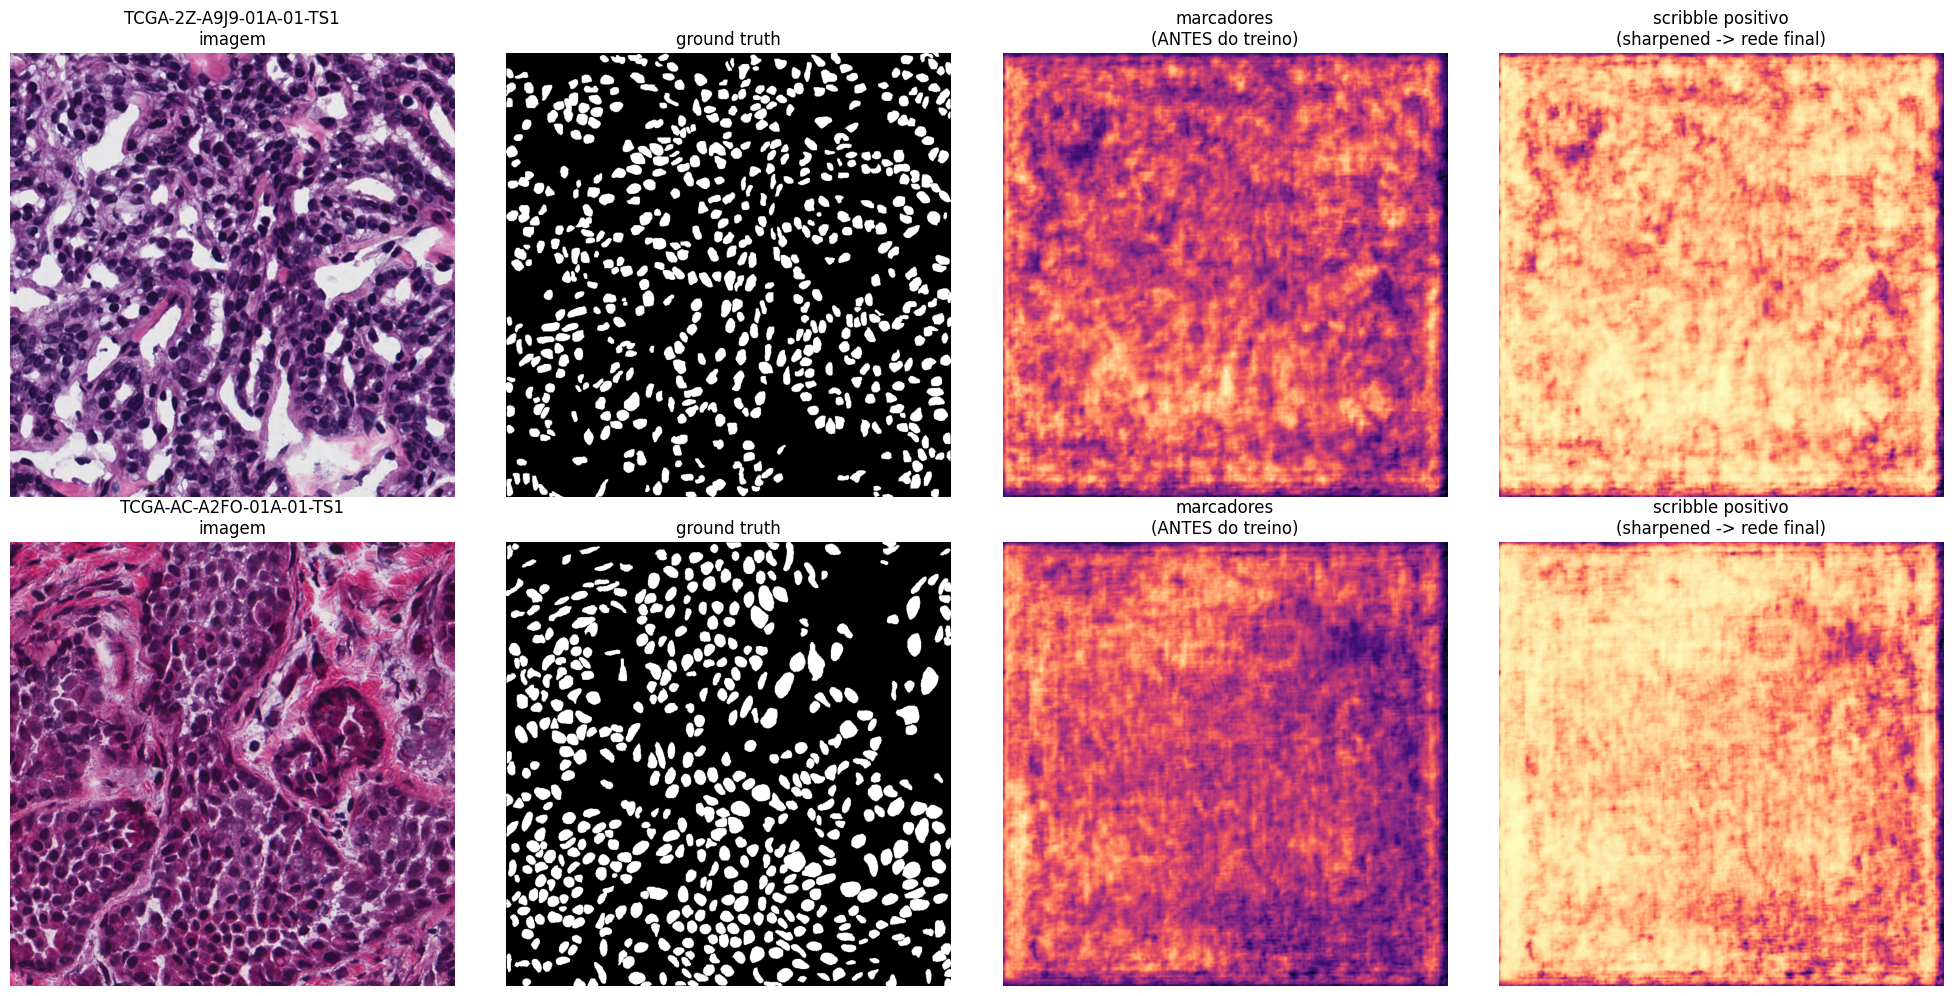

MarkerNet de volta a train(): True


In [19]:
# --- Marcadores ANTES do treino (linha de base) ---
# Rede recém-inicializada: o que a MarkerNet produz antes de qualquer otimização.
def tensor_to_np(t, i=0):
    return t.detach().cpu().numpy()[i, 0]


def to_scribbles_vis(net, markers_tensor):
    """Scribbles que a rede final recebe (sharpened no ScribblePrompt; [s, 1-s] na Dummy)."""
    if hasattr(net, "_prepare_scribbles"):
        return net._prepare_scribbles(markers_tensor, DEVICE)  # (N, 2, H, W)
    s = markers_tensor.float()
    return torch.cat([s, 1.0 - s], dim=1)


marker_net.model.eval()
N = min(2, len(val_batches))
fig, axes = plt.subplots(N, 4, figsize=(20, 5 * N))
if N == 1:
    axes = axes[None, :]

for row, batch in enumerate(val_batches[:N]):
    with torch.no_grad():
        out = training_pipeline.run(batch, verbose=False)

    img = batch["image"][0].permute(1, 2, 0).numpy()
    if img.max() > 1.0:
        img = img / 255.0
    gt = tensor_to_np(batch["ground_truth"])
    markers = tensor_to_np(out["markers"])
    scrib_pos = to_scribbles_vis(FINAL_NET, out["markers"])[0, 0].cpu().numpy()

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{batch['id'][0]}\nimagem")
    axes[row, 1].imshow(gt, cmap="gray")
    axes[row, 1].set_title("ground truth")
    axes[row, 2].imshow(markers, cmap="magma")
    axes[row, 2].set_title("marcadores\n(ANTES do treino)")
    axes[row, 3].imshow(scrib_pos, cmap="magma")
    axes[row, 3].set_title("scribble positivo\n(sharpened -> rede final)")

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()
marker_net.model.train()
print("MarkerNet de volta a train():", marker_net.model.training)


## 8. Treinamento — LossComposer + Trainer + TrainingLoop

Executamos **50 épocas** com **batches de 4 imagens de treino** e **validação a cada época**
(14 imagens oficiais de teste). A loss é composta por **Dice + RMSE + Size + DMap**:

- `Dice`/`RMSE`/`Size` supervisionam a **segmentação final** (saída da rede congelada);
- `DMap` supervisiona os **marcadores diretamente** (P11/C3/C4): penaliza ativação dos marcadores em
  bordas/fundo, empurrando-os para o interior das células;
- `Size` agora é **simétrico** (P10): penaliza tanto superestimar quanto subestimar a massa, com ótimo
  em pred.sum() == gt.sum().

Hiperparâmetros: lr 1e-4 com CosineAnnealing, **grad clip 1.0** (P5) e callback de **grad-norm** (E1).

> **Tempo estimado:** cada batch em GPU leva ~0,5–2s no forward/backward; com 8 batches × 50 épocas,
> espere de ~5 a 30 minutos dependendo da GPU.

In [20]:
composer = LossComposer([
    DiceTerm(),
    RMSETerm(),
    SizeTerm(weight=0.05),   # simétrico em torno de 1.0 (P10)
    DMapTerm(weight=0.1),    # supervisão direta dos marcadores (P11/C3/C4)
    TVTerm(weight=0.01),      # regularização de suavidade (P12)
    BorderTerm(weight=0.01),  # regularização de borda (P13) 
])

optimizer = torch.optim.Adam(marker_net.parameters(), lr=1e-4)  # lr menor (E6)
NUM_EPOCHS = 50
total_steps = NUM_EPOCHS * len(train_batches)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

# Diagnóstico de gradiente morto (P1/E1): acompanha a norma L2 dos gradientes da MarkerNet.
grad_norm_cb = GradNormCallback(log_every=1)

trainer = Trainer(
    training_pipeline=training_pipeline,
    loss_composer=composer,
    optimizer=optimizer,
    scheduler=scheduler,
    grad_clip=1.0,           # P5
    callbacks=[grad_norm_cb],
    device=DEVICE,
)

loop = TrainingLoop(
    trainer=trainer,
    train_loader=train_batches,
    val_loader=val_batches,
    num_epochs=NUM_EPOCHS,
    validate_every=1,
    log_every=5,
)

history = loop.run()
print("train_loss:", [f"{x:.4f}" for x in history["train_loss"]])
print("val_loss:", [f"{x:.4f}" for x in history["val_loss"]])
print("terms:", {k: [f"{v:.4f}" for v in vals] for k, vals in history["train_terms"].items()})
print("grad_norm (total):", [f"{v:.3e}" for v in grad_norm_cb.history["total"]])


2026-08-16 19:30:24.630 | INFO     | src.training.trainer:__init__:150 - [Trainer] Initialized on cuda
2026-08-16 19:30:24.684 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:130 - [MarkerStep] Generated markers with shape (4, 1, 1000, 1000)
2026-08-16 19:30:24.706 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (4, 1, 1000, 1000)
2026-08-16 19:30:25.055 | INFO     | src.training.callbacks.grad_norm_callback:on_train_step_end:78 - [GradNorm] step=1 | total=1.000e+00 | mean_abs=9.882e-04 | max_abs=1.480e-02 | nonzero_frac=1.000
2026-08-16 19:30:25.102 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:130 - [MarkerStep] Generated markers with shape (4, 1, 1000, 1000)
2026-08-16 19:30:25.117 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (4, 1, 1000, 1000)
2026-08-16 19:30:25.258 |

train_loss: ['2.8986', '2.2662', '1.7578', '1.4785', '1.3371', '1.2931', '1.2666', '1.2450', '1.2231', '1.2067', '1.1925', '1.1820', '1.1747', '1.1685', '1.1624', '1.1590', '1.1495', '1.1424', '1.1391', '1.1347', '1.1282', '1.1265', '1.1240', '1.1204', '1.1144', '1.1097', '1.1065', '1.1039', '1.0995', '1.0953', '1.0919', '1.0887', '1.0862', '1.0838', '1.0811', '1.0790', '1.0765', '1.0746', '1.0730', '1.0716', '1.0704', '1.0695', '1.0686', '1.0680', '1.0676', '1.0673', '1.0671', '1.0669', '1.0669', '1.0669']
val_loss: ['2.7129', '2.1814', '1.8022', '1.5694', '1.4224', '1.3836', '1.3619', '1.3423', '1.3292', '1.3269', '1.3147', '1.3014', '1.3019', '1.2971', '1.2868', '1.2861', '1.2943', '1.2941', '1.2815', '1.2797', '1.2814', '1.2899', '1.2809', '1.2817', '1.2763', '1.2808', '1.2742', '1.2742', '1.2770', '1.2774', '1.2785', '1.2775', '1.2797', '1.2812', '1.2775', '1.2802', '1.2787', '1.2794', '1.2788', '1.2793', '1.2791', '1.2788', '1.2792', '1.2792', '1.2792', '1.2793', '1.2793', '1.279

## 9. Curvas de loss e grad-norm

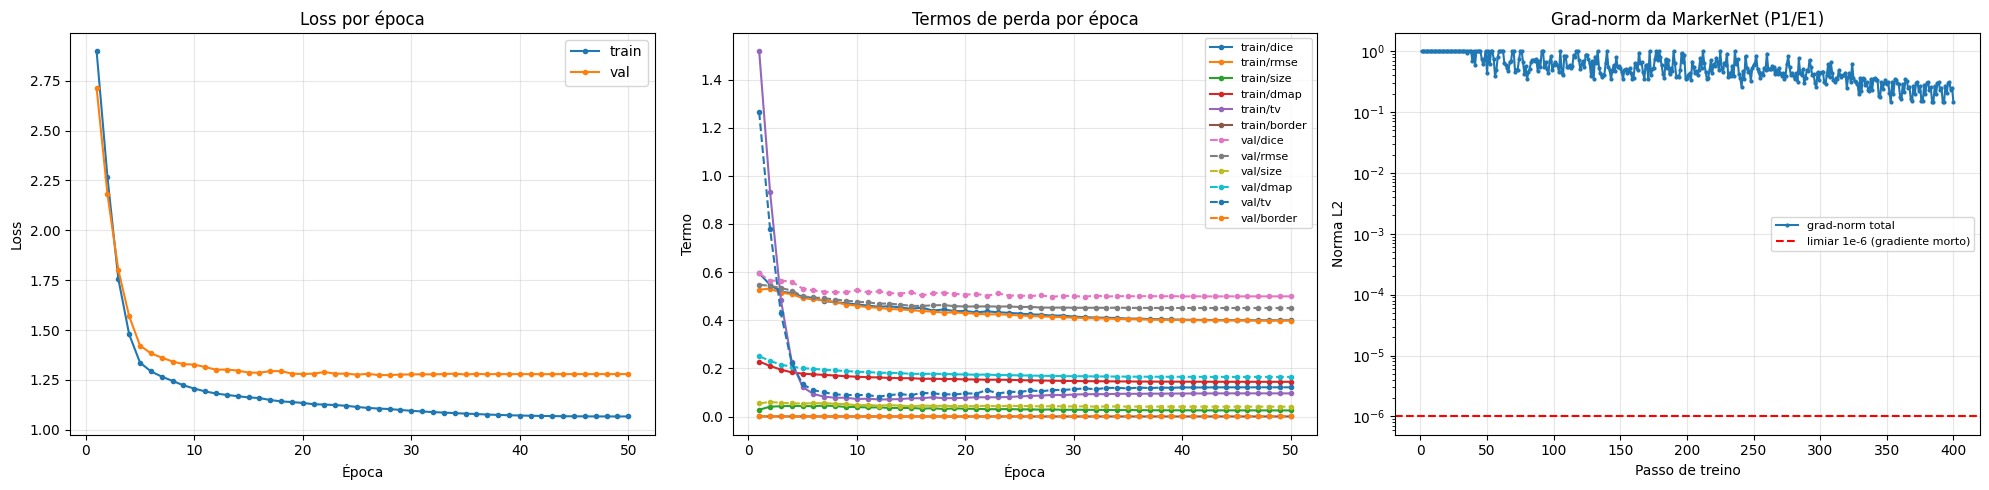

In [21]:
epochs = list(range(1, NUM_EPOCHS + 1))
steps = list(range(1, len(grad_norm_cb.history["total"]) + 1))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(epochs, history["train_loss"], label="train", marker="o", ms=3)
axes[0].plot(epochs, history["val_loss"], label="val", marker="o", ms=3)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss por época")
axes[0].legend()
axes[0].grid(alpha=0.3)

for name, vals in history["train_terms"].items():
    axes[1].plot(epochs, vals, label=f"train/{name}", marker="o", ms=3)
for name, vals in history["val_terms"].items():
    axes[1].plot(epochs, vals, label=f"val/{name}", marker="o", ms=3, linestyle="--")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Termo")
axes[1].set_title("Termos de perda por época")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

axes[2].plot(steps, grad_norm_cb.history["total"], label="grad-norm total", marker="o", ms=2)
axes[2].axhline(1e-6, color="red", linestyle="--", label="limiar 1e-6 (gradiente morto)")
axes[2].set_yscale("log")
axes[2].set_xlabel("Passo de treino")
axes[2].set_ylabel("Norma L2")
axes[2].set_title("Grad-norm da MarkerNet (P1/E1)")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Validações finais

In [22]:
import math

tl = history["train_loss"]
vl = history["val_loss"]

assert len(tl) == NUM_EPOCHS, f"Deveria haver {NUM_EPOCHS} épocas de treino"
assert len(vl) == NUM_EPOCHS, f"Deveria haver {NUM_EPOCHS} épocas de validação"
assert all(math.isfinite(x) for x in tl), "train_loss não é finita!"
assert all(math.isfinite(x) for x in vl), "val_loss não é finita!"

print(f"OK: todas as losses são finitas ({NUM_EPOCHS} épocas).")
print(f"train_loss: {tl[0]:.4f} -> {tl[-1]:.4f}")
print(f"val_loss:   {vl[0]:.4f} -> {vl[-1]:.4f}")

if tl[-1] < tl[0]:
    print(f"OK: loss de treino decresceu {tl[0]:.4f} -> {tl[-1]:.4f}")
else:
    print(f"[info] train_loss não decresceu ({tl[0]:.4f} -> {tl[-1]:.4f}) - confira o grad-norm acima")

print("\nTREINAMENTO COMPLETO!")
print(f"Melhor val_loss: {min(vl):.4f} (época {vl.index(min(vl)) + 1})")


OK: todas as losses são finitas (50 épocas).
train_loss: 2.8986 -> 1.0669
val_loss:   2.7129 -> 1.2793
OK: loss de treino decresceu 2.8986 -> 1.0669

TREINAMENTO COMPLETO!
Melhor val_loss: 1.2742 (época 27)


## 11. Visualização — predições nas imagens de validação (teste oficial)

2026-08-16 19:31:55.861 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:130 - [MarkerStep] Generated markers with shape (4, 1, 1000, 1000)
2026-08-16 19:31:55.903 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (4, 1, 1000, 1000)
2026-08-16 19:31:55.997 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:130 - [MarkerStep] Generated markers with shape (4, 1, 1000, 1000)
2026-08-16 19:31:56.044 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (4, 1, 1000, 1000)
2026-08-16 19:31:56.122 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:130 - [MarkerStep] Generated markers with shape (4, 1, 1000, 1000)
2026-08-16 19:31:56.161 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (4, 1, 1000

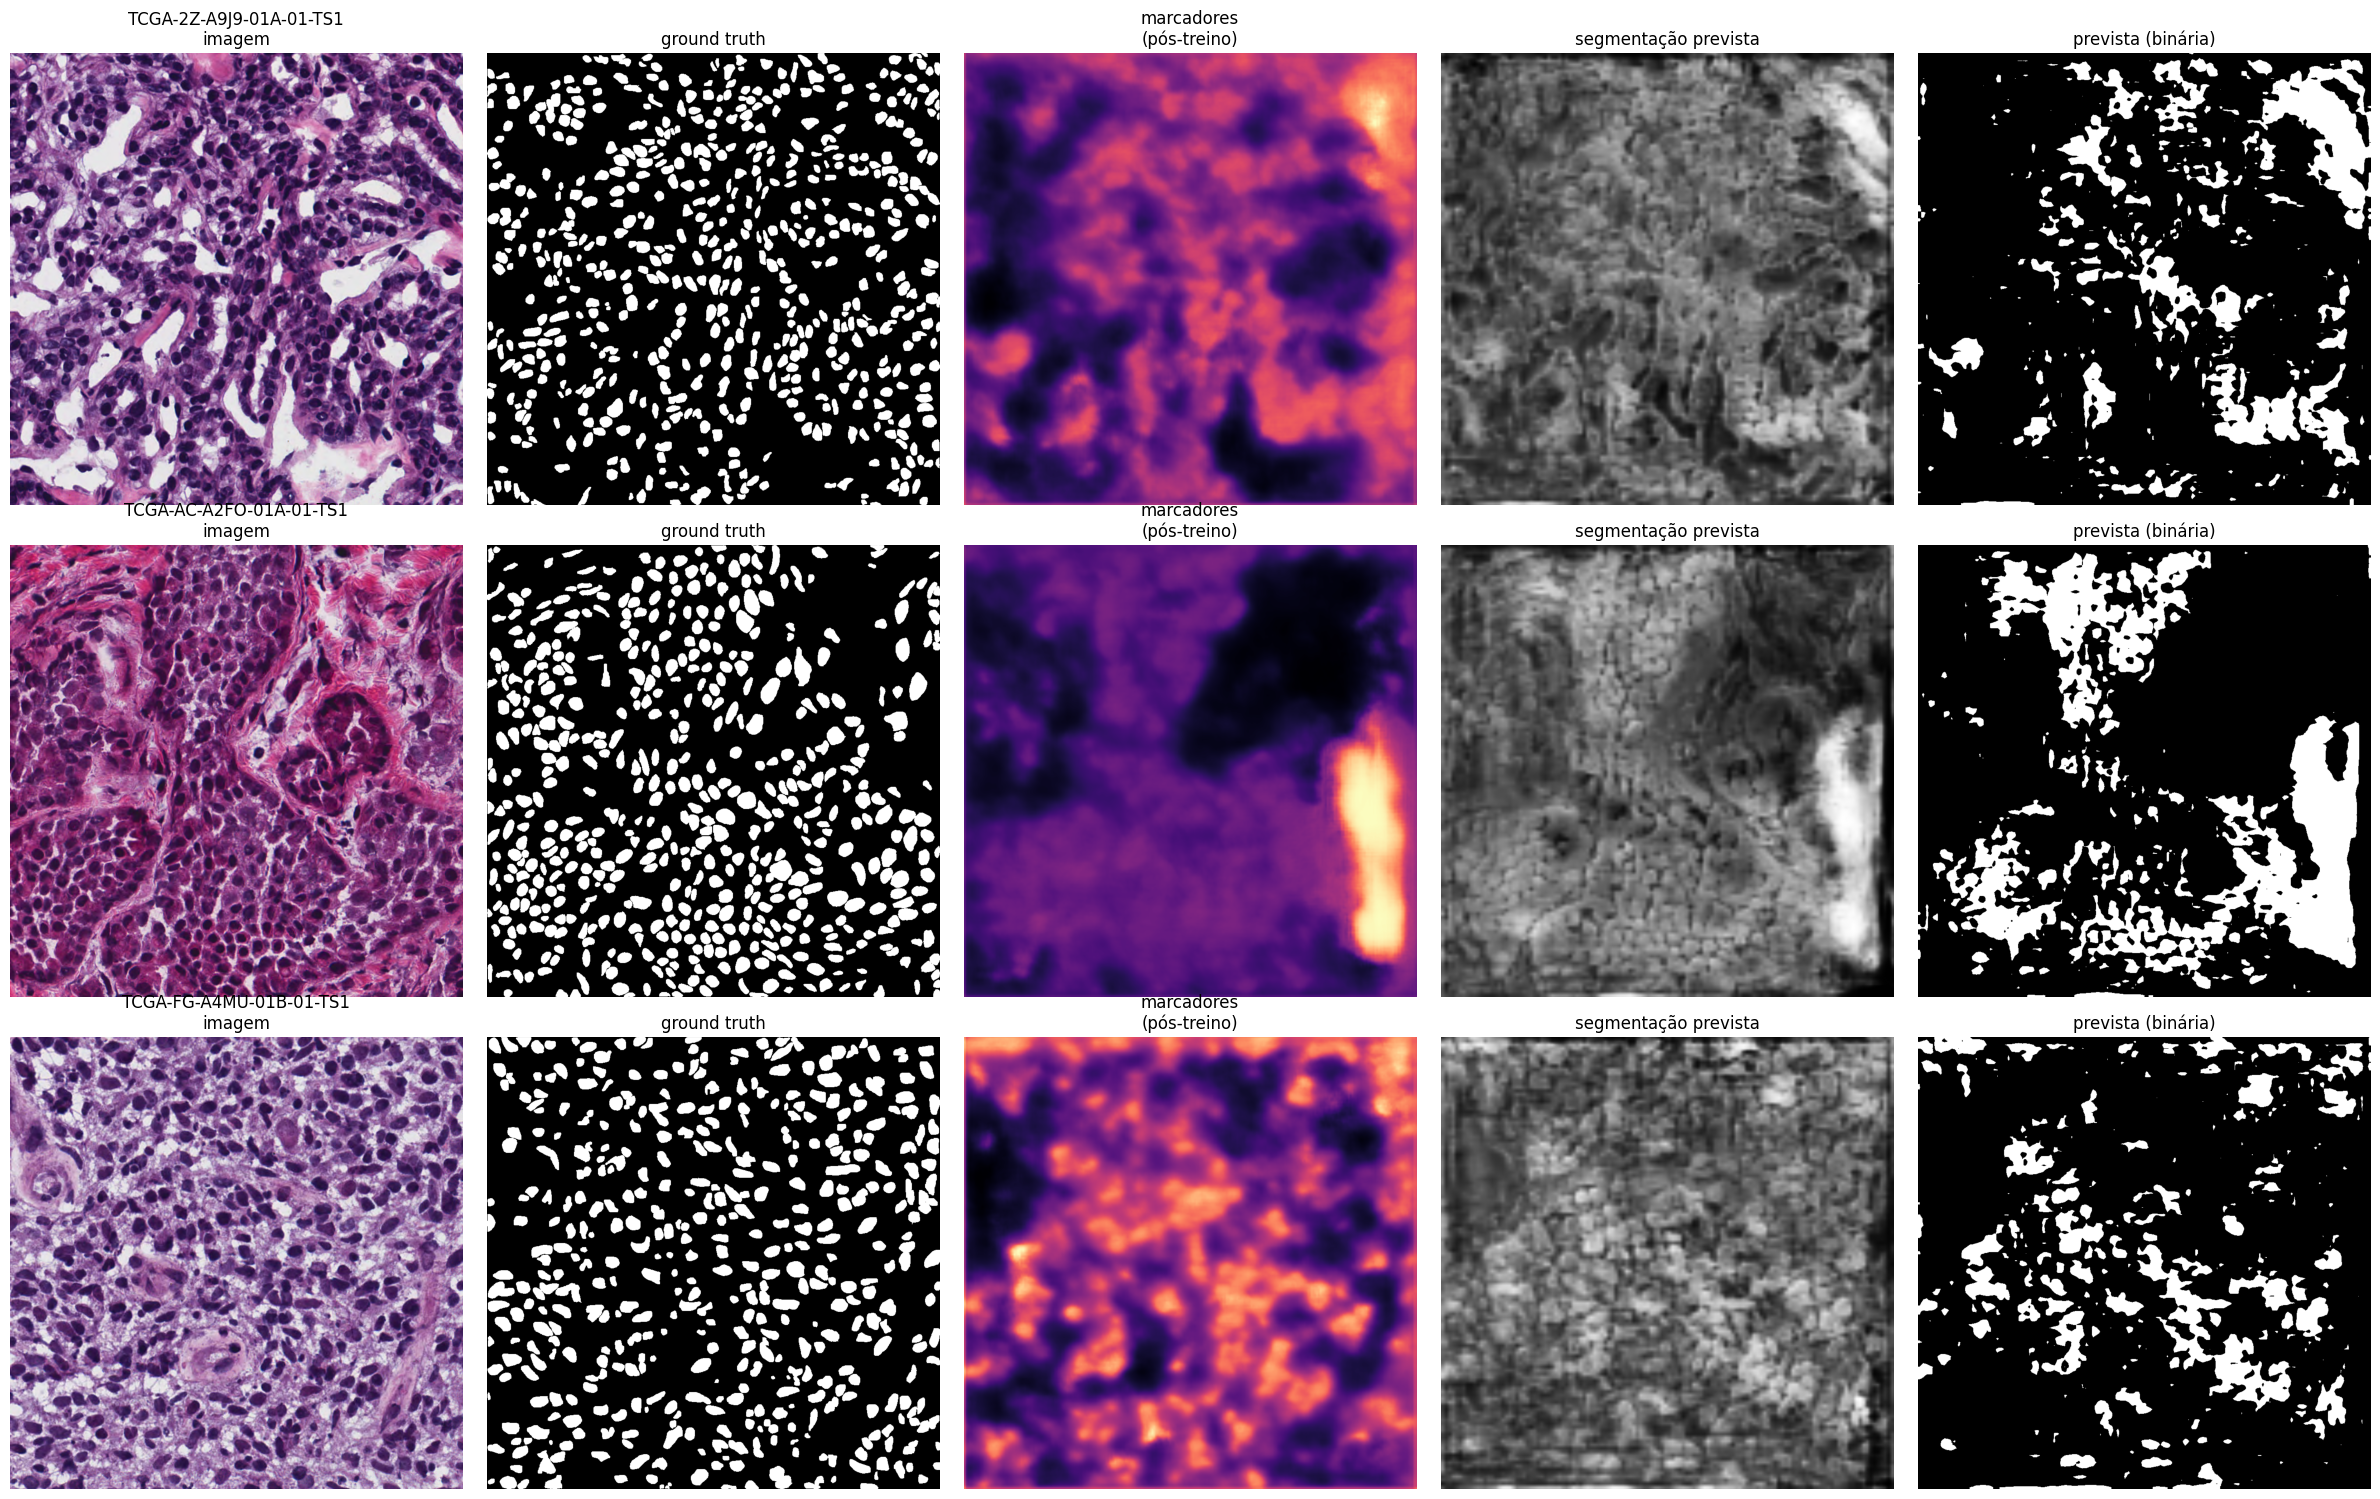

In [23]:
def tensor_to_np(t, i=0):
    return t.detach().cpu().numpy()[i, 0]


N = min(3, len(val_batches))
fig, axes = plt.subplots(N, 5, figsize=(24, 5 * N))  # 5 colunas: agora inclui marcadores
if N == 1:
    axes = axes[None, :]

for row, batch in enumerate(val_batches[:N]):
    with torch.no_grad():
        out = training_pipeline.run(batch, verbose=False)

    img = batch["image"][0].permute(1, 2, 0).numpy()
    if img.max() > 1.0:
        img = img / 255.0
    gt = tensor_to_np(batch["ground_truth"])
    markers = tensor_to_np(out["markers"])
    seg = tensor_to_np(out["segmentation"])

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{batch['id'][0]}\nimagem")
    axes[row, 1].imshow(gt, cmap="gray")
    axes[row, 1].set_title("ground truth")
    axes[row, 2].imshow(markers, cmap="magma")
    axes[row, 2].set_title("marcadores\n(pós-treino)")
    axes[row, 3].imshow(seg, cmap="gray")
    axes[row, 3].set_title("segmentação prevista")
    axes[row, 4].imshow(seg > 0.5, cmap="gray")
    axes[row, 4].set_title("prevista (binária)")

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()


## 12. Salvar checkpoint

Salva os pesos da **MarkerNet treinada** em `checkpoints/marker_net_trained.pt` para uso posterior em
inferência, junto com a configuração completa do run (P12/E8).

In [24]:
os.makedirs("checkpoints", exist_ok=True)
ckpt_path = os.path.join("checkpoints", "marker_net_trained.pt")

torch.save(
    {
        "state_dict": marker_net.state_dict(),
        "config": UNET_CONFIG,
        "epochs": NUM_EPOCHS,
        "size": WORK_SIZE,
        "batch_size": BATCH_SIZE,
        "best_val_loss": min(history["val_loss"]),
        "grad_norm_mean": float(np.mean(grad_norm_cb.history["total"])),
    },
    ckpt_path,
)
print(f"Checkpoint salvo em {ckpt_path}")
print("Arquivos em checkpoints/:", os.listdir("checkpoints"))


Checkpoint salvo em checkpoints/marker_net_trained.pt
Arquivos em checkpoints/: ['marker_net_trained.pt', 'ScribblePrompt_unet_v1_nf192_res128.pt']
